In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Models (Supervised ML)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

## Cross Validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

## System utilities
import warnings
warnings.filterwarnings("ignore")

In [2]:
lateral_df=pd.read_csv(r"C:\Users\USER\Downloads\lateral_movement_attack_dataset_large.csv")
lateral_df

,host_id,edge_id,source_ip_risk,destination_ip_risk,vulnerability_score,privilege_level,connection_type,anomaly_score,failed_login_attempts,suspicious_process,lateral_movement
0,103,32,0.857097,0.284871,2,low,api,0.405914,9,0,0
1,180,55,0.817107,0.752473,8,low,rdp,0.920862,9,0,1
2,93,352,0.448346,0.030605,2,medium,rdp,0.080561,8,1,0
3,15,389,0.489239,0.283311,3,low,ssh,0.777134,18,1,0
4,107,36,0.217749,0.498634,8,medium,rdp,0.395534,10,0,0
...,...,...,...,...,...,...,...,...,...,...,...
4995,52,468,0.515497,0.221469,7,low,rdp,0.967826,11,0,0
4996,88,2,0.261493,0.086266,1,low,api,0.222973,8,0,0
4997,153,243,0.722647,0.416719,1,low,rdp,0.214562,16,1,1
4998,55,297,0.321351,0.617973,6,medium,smb,0.057218,13,0,0


In [3]:
# Inspect datasets
print(lateral_df.head())

   host_id  edge_id  source_ip_risk  destination_ip_risk  vulnerability_score  \
0      103       32        0.857097             0.284871                    2   
1      180       55        0.817107             0.752473                    8   
2       93      352        0.448346             0.030605                    2   
3       15      389        0.489239             0.283311                    3   
4      107       36        0.217749             0.498634                    8   

  privilege_level connection_type  anomaly_score  failed_login_attempts  \
0             low             api       0.405914                      9   
1             low             rdp       0.920862                      9   
2          medium             rdp       0.080561                      8   
3             low             ssh       0.777134                     18   
4          medium             rdp       0.395534                     10   

   suspicious_process  lateral_movement  
0                   

In [4]:
print(lateral_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   host_id                5000 non-null   int64  
 1   edge_id                5000 non-null   int64  
 2   source_ip_risk         5000 non-null   float64
 3   destination_ip_risk    5000 non-null   float64
 4   vulnerability_score    5000 non-null   int64  
 5   privilege_level        5000 non-null   object 
 6   connection_type        5000 non-null   object 
 7   anomaly_score          5000 non-null   float64
 8   failed_login_attempts  5000 non-null   int64  
 9   suspicious_process     5000 non-null   int64  
 10  lateral_movement       5000 non-null   int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 429.8+ KB
None


In [5]:
print(lateral_df.describe())

           host_id      edge_id  source_ip_risk  destination_ip_risk  \
count  5000.000000  5000.000000     5000.000000          5000.000000   
mean    100.444800   250.056600        0.501396             0.501500   
std      57.376805   144.441347        0.288440             0.287122   
min       1.000000     1.000000        0.000185             0.000119   
25%      51.000000   124.000000        0.259748             0.253880   
50%     102.000000   248.000000        0.503567             0.502675   
75%     150.000000   377.000000        0.747623             0.744356   
max     199.000000   499.000000        0.999849             0.999893   

       vulnerability_score  anomaly_score  failed_login_attempts  \
count           5000.00000    5000.000000            5000.000000   
mean               4.44320       0.493514               9.353800   
std                2.86119       0.287647               5.754898   
min                0.00000       0.000068               0.000000   
25%        

In [6]:
print(lateral_df.isnull().sum())

host_id                  0
edge_id                  0
source_ip_risk           0
destination_ip_risk      0
vulnerability_score      0
privilege_level          0
connection_type          0
anomaly_score            0
failed_login_attempts    0
suspicious_process       0
lateral_movement         0
dtype: int64


In [7]:
print(lateral_df.duplicated().sum())

0


In [8]:
print(lateral_df['lateral_movement'].value_counts(normalize=True))## for checking target variable is balanced

lateral_movement
0    0.7438
1    0.2562
Name: proportion, dtype: float64


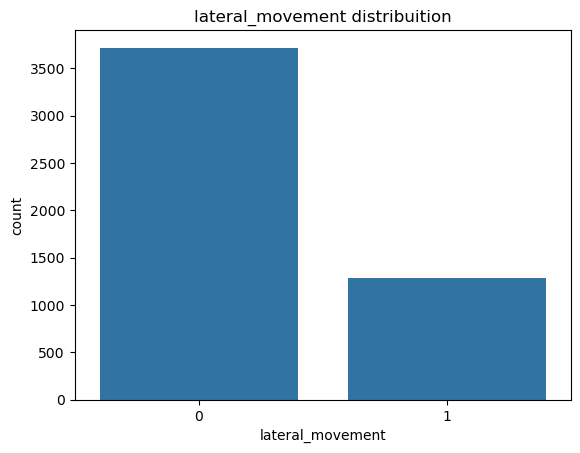

In [9]:
## to check if target variable is balanced or imbalanced like how many safe orders and how many risky orders if one class
## is very samll the model will become biased  if 95|% are safe and 5% are rikly the data is imbalanced to check this we are doing countplot

sns.countplot(data=lateral_df,x='lateral_movement')
plt.title("lateral_movement distribuition")
plt.show() ## here data is imbalanced

In [10]:
print(lateral_df.dtypes)

host_id                    int64
edge_id                    int64
source_ip_risk           float64
destination_ip_risk      float64
vulnerability_score        int64
privilege_level           object
connection_type           object
anomaly_score            float64
failed_login_attempts      int64
suspicious_process         int64
lateral_movement           int64
dtype: object


In [3]:
from sklearn.preprocessing import LabelEncoder
obj1=LabelEncoder()
obj2=LabelEncoder()
lateral_df['privilege_level']=obj1.fit_transform(lateral_df['privilege_level'])
lateral_df['connection_type']=obj2.fit_transform(lateral_df['connection_type'])
lateral_df

,host_id,edge_id,source_ip_risk,destination_ip_risk,vulnerability_score,privilege_level,connection_type,anomaly_score,failed_login_attempts,suspicious_process,lateral_movement
0,103,32,0.857097,0.284871,2,1,0,0.405914,9,0,0
1,180,55,0.817107,0.752473,8,1,1,0.920862,9,0,1
2,93,352,0.448346,0.030605,2,2,1,0.080561,8,1,0
3,15,389,0.489239,0.283311,3,1,3,0.777134,18,1,0
4,107,36,0.217749,0.498634,8,2,1,0.395534,10,0,0
...,...,...,...,...,...,...,...,...,...,...,...
4995,52,468,0.515497,0.221469,7,1,1,0.967826,11,0,0
4996,88,2,0.261493,0.086266,1,1,0,0.222973,8,0,0
4997,153,243,0.722647,0.416719,1,1,1,0.214562,16,1,1
4998,55,297,0.321351,0.617973,6,2,2,0.057218,13,0,0


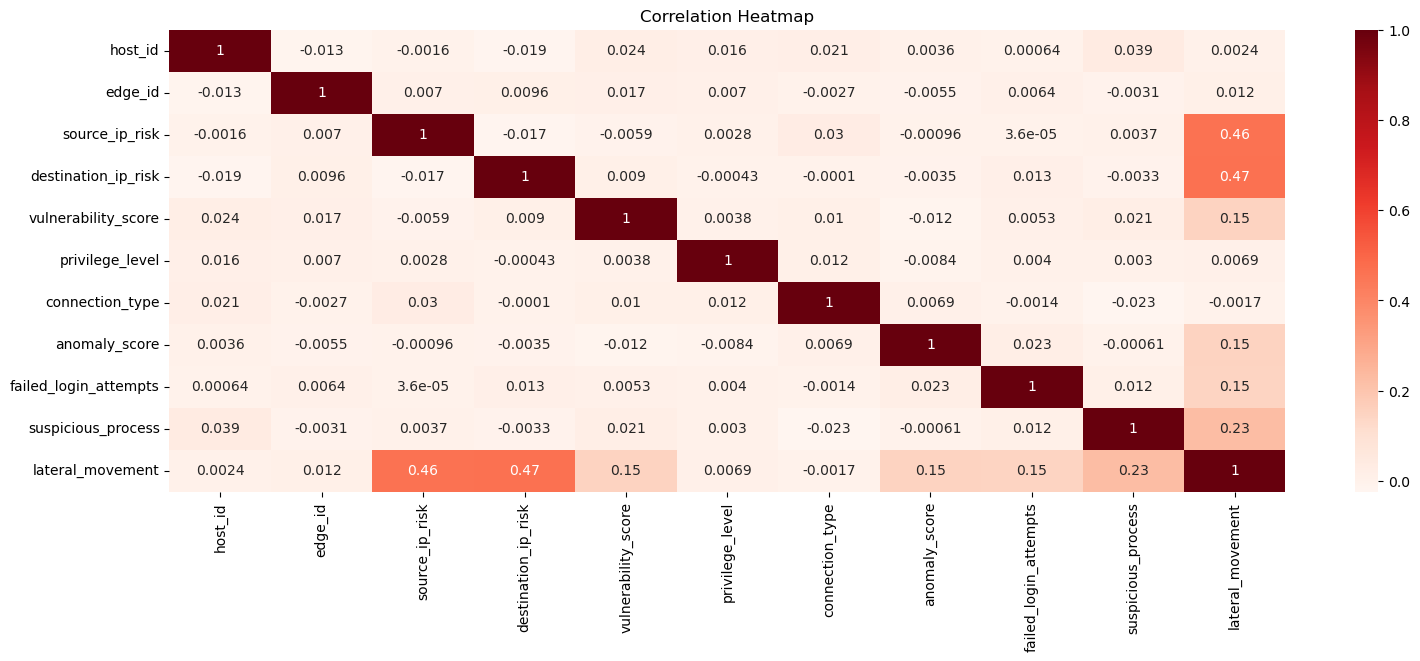

In [12]:
plt.figure(figsize=(18,6))
sns.heatmap(lateral_df.corr(), annot=True, cmap='Reds')
plt.title("Correlation Heatmap")
plt.show()

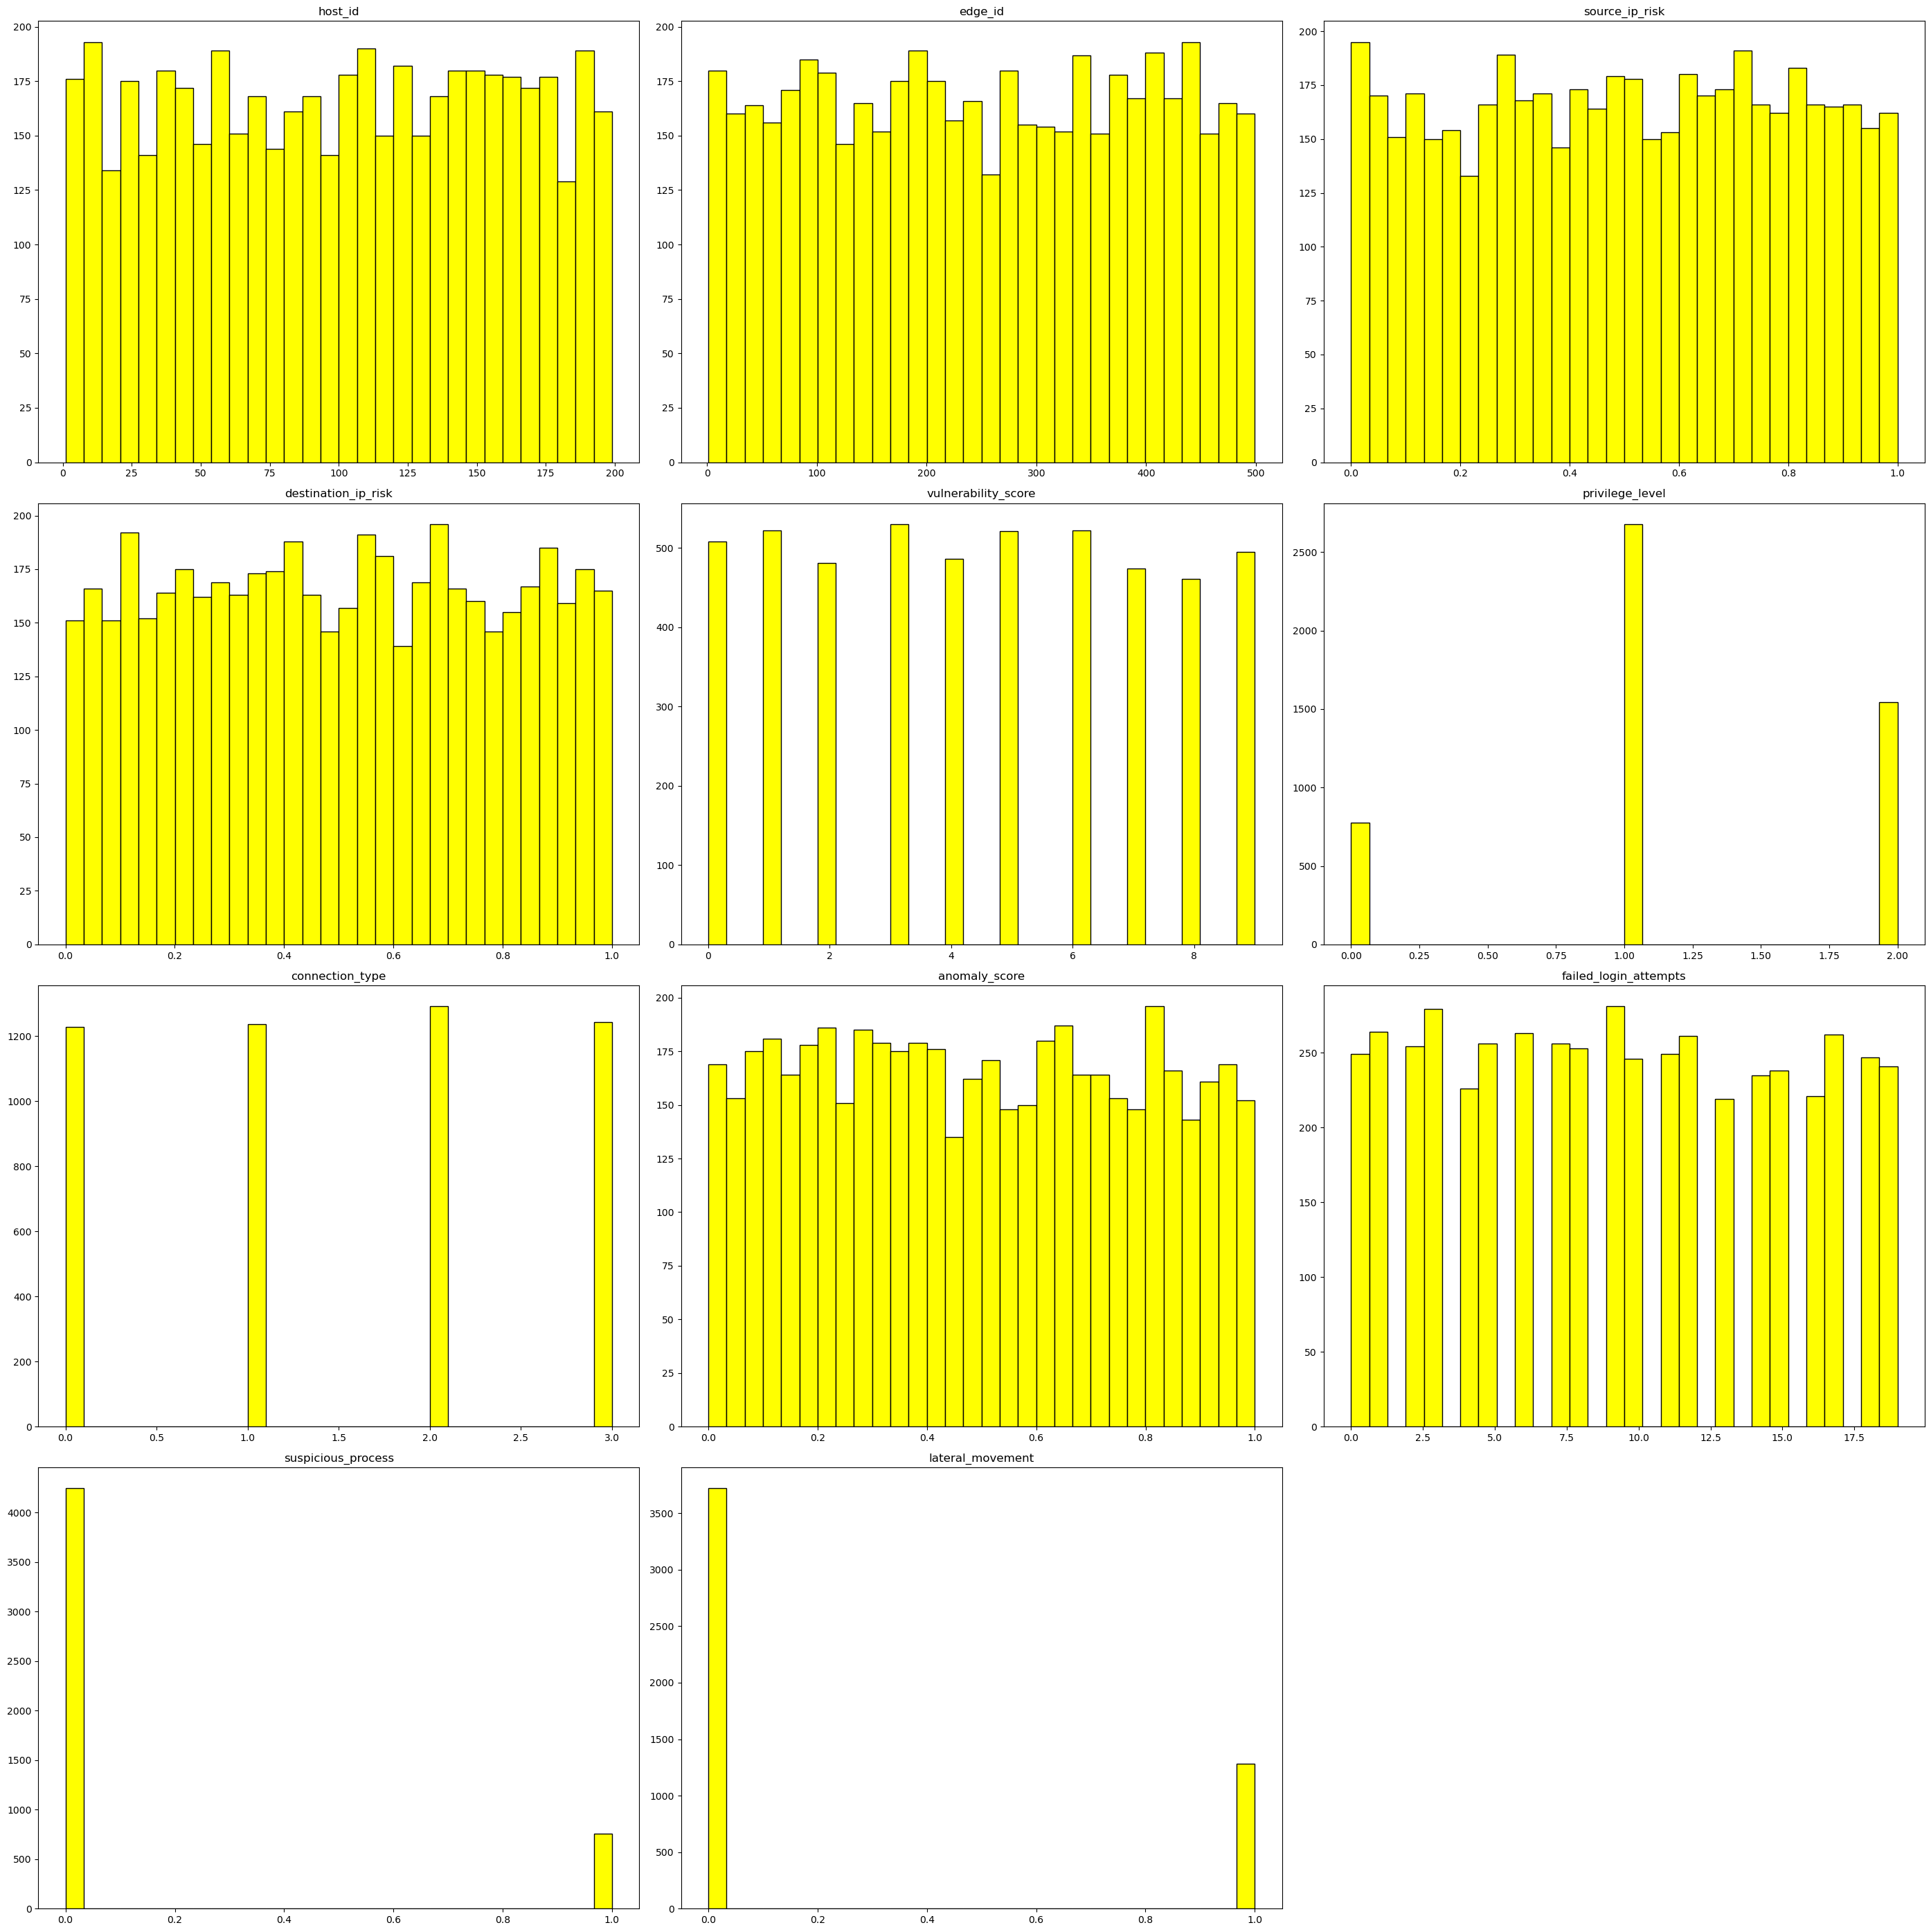

In [13]:
# Select numeric columns
numeric_cols_host = lateral_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Number of features
n = len(numeric_cols_host)

# Create grid of subplots (3 columns)
rows = (n + 2) // 3
cols = 3

plt.figure(figsize=(28, 7 * rows))

for i, col in enumerate(numeric_cols_host, 1):
    plt.subplot(rows, cols, i)
    plt.hist(lateral_df[col], bins=30,color='yellow', edgecolor='black')
    plt.title(col)
    plt.tight_layout()

plt.show()

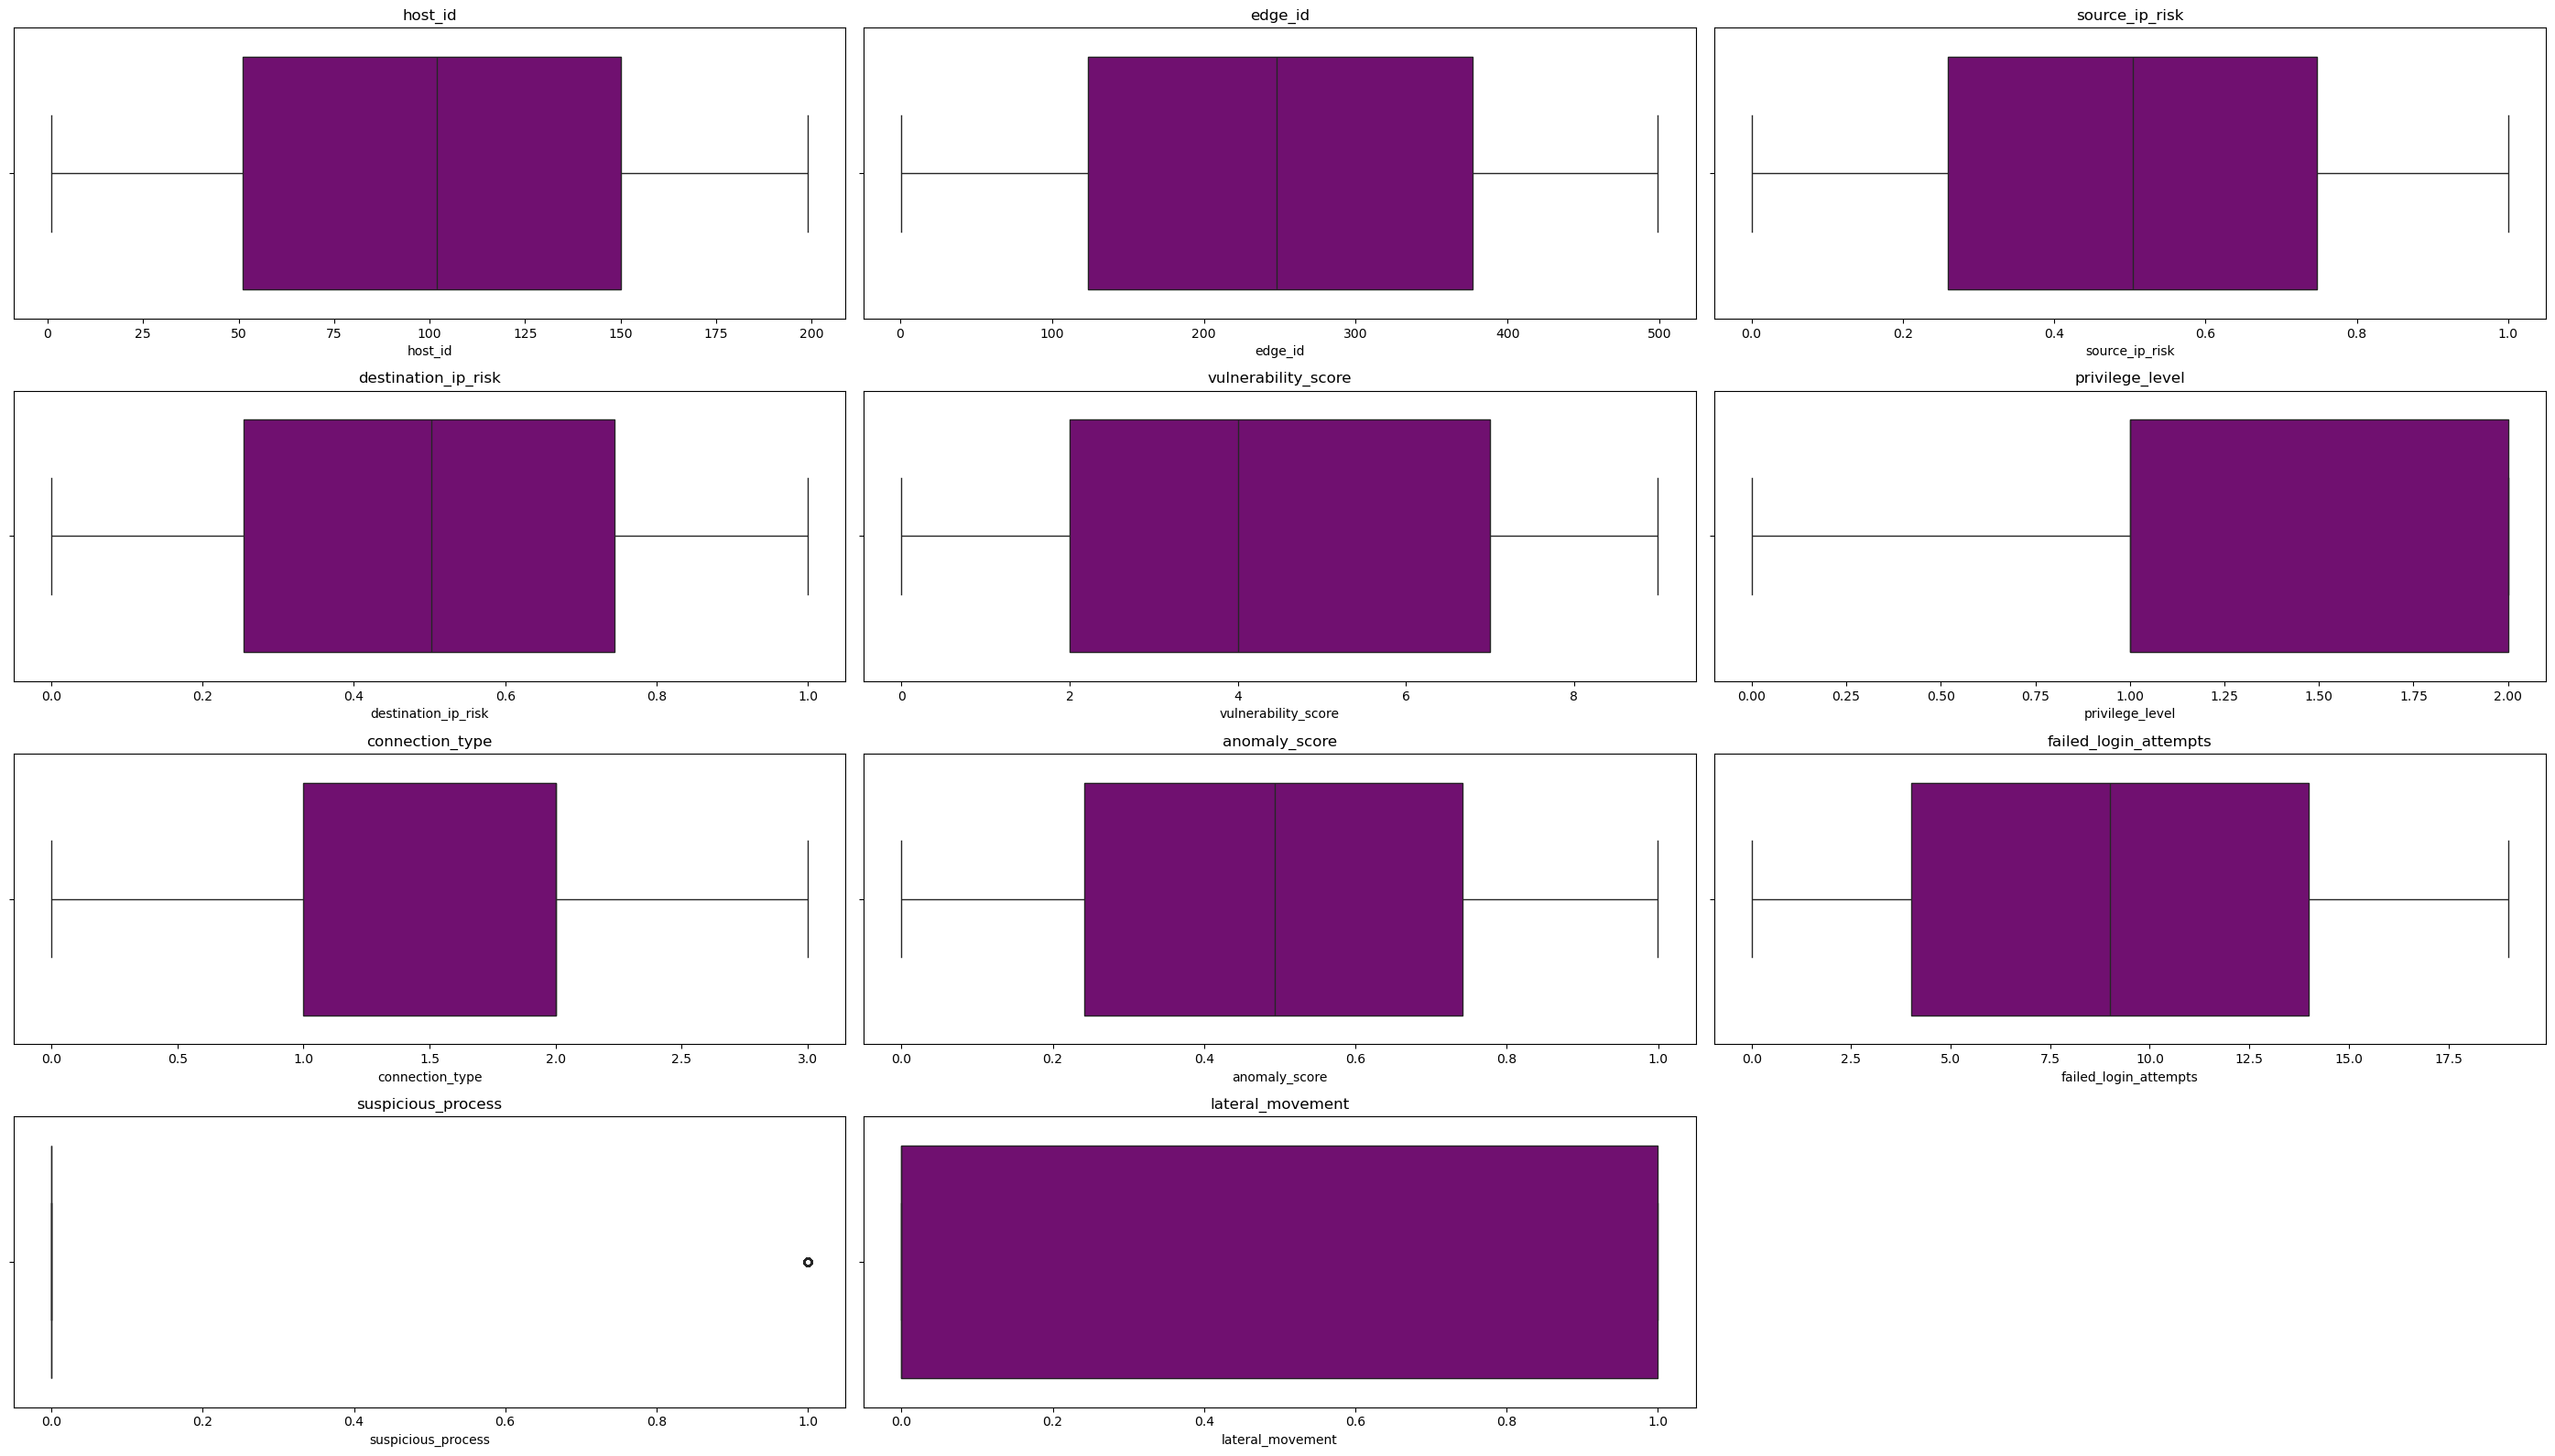

In [14]:
# Select only numeric columns
numeric_cols_host = lateral_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Number of numeric features
n = len(numeric_cols_host)

# Setup subplot grid (3 columns)
rows = (n + 2) // 3   # calculates number of rows automatically
cols = 3

plt.figure(figsize=(28, 4 * rows))

for i, col in enumerate(numeric_cols_host, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=lateral_df[col],color='purple')
    plt.title(col)
    plt.tight_layout()

plt.show()

In [4]:
x = lateral_df.drop('lateral_movement', axis=1)
y = lateral_df['lateral_movement']

In [5]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.2, random_state=1)

In [6]:
sm = SMOTE(random_state=1)
X_train, Y_train = sm.fit_resample(xtrain, ytrain)

In [7]:
from sklearn.metrics import accuracy_score
import pandas as pd

# Dictionary to store models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100,random_state=9),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100,random_state=9),
    "XGBoost": XGBClassifier(n_estimators=100,random_state=9),
    "Decision tree": DecisionTreeClassifier()
}
for name, model in models.items():
    model.fit(X_train, Y_train)
    pred = model.predict(xtest)
    print(name, accuracy_score(ytest, pred))

Logistic Regression 0.779
Random Forest 0.919
Gradient Boosting 0.933
XGBoost 0.932
Decision tree 0.891


In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
import numpy as np

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=1),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=34),
    "Decision tree": DecisionTreeClassifier()
    
}

# StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=34)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, Y_train, cv=skf, scoring='accuracy')
    print(f"Model: {name}")
    print("Fold Accuracies:", cv_scores)

Model: Logistic Regression
Fold Accuracies: [0.81833474 0.83851976 0.8526936  0.91329966 0.80555556]
Model: Random Forest
Fold Accuracies: [0.93187553 0.93776283 0.93265993 0.94360269 0.92508418]
Model: Gradient Boosting
Fold Accuracies: [0.93103448 0.94365013 0.94023569 0.94276094 0.92592593]
Model: XGBoost
Fold Accuracies: [0.94028595 0.94953743 0.94781145 0.9503367  0.93350168]
Model: Decision tree
Fold Accuracies: [0.88393608 0.89234651 0.89225589 0.89225589 0.87962963]


In [8]:
model_params = {
    'random_forest' : {'model' : RandomForestClassifier(),'params':{'n_estimators':[100,205,350]}},
    'xgboost' : {'model' : XGBClassifier(),'params':{'n_estimators':[100,205,350]}}
}
scores = []
models = ['random_forest','xgboost']
for modelname in model_params:
    mp = model_params[modelname]
    gds = GridSearchCV(mp['model'],mp['params'],cv=5,return_train_score=True)
    gds.fit(X_train, Y_train)
    scores.append({'model':modelname,'best_score':gds.best_score_,'best_params':gds.best_params_})
df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

,model,best_score,best_params
0,random_forest,0.933360,{'n_estimators': 205}
1,xgboost,0.946482,{'n_estimators': 205}


In [9]:
finalhost = XGBClassifier(
    n_estimators=205
)

finalhost.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=205,
              n_jobs=None, num_parallel_tree=None, ...)

 HOST MODEL ACCURACY: 0.936

 HOST CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.98      0.94      0.96       748
           1       0.83      0.93      0.88       252

    accuracy                           0.94      1000
   macro avg       0.90      0.93      0.92      1000
weighted avg       0.94      0.94      0.94      1000



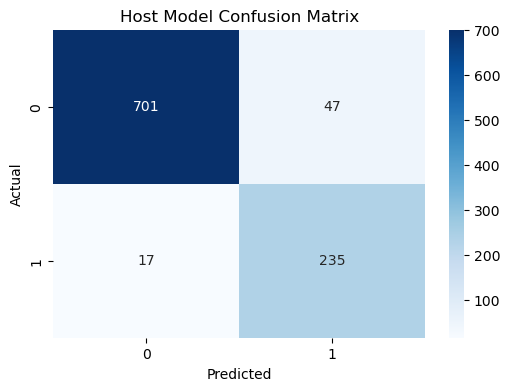

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
ypred1 = finalhost.predict(xtest)

# Accuracy
print(" HOST MODEL ACCURACY:", accuracy_score(ytest, ypred1))

# Classification Report
print("\n HOST CLASSIFICATION REPORT:\n")
print(classification_report(ytest, ypred1))

# Confusion Matrix
cm_host = confusion_matrix(ytest, ypred1)
plt.figure(figsize=(6,4))
sns.heatmap(cm_host, annot=True, fmt='d', cmap='Blues')
plt.title("Host Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
!pip install gradio

In [13]:
import gradio as gr
def predict_lateral(host_id, edge_id, src_risk, dst_risk, vuln_score,
                    privilege_level, connection_type, anomaly_score,
                    failed_logins, susp_process):

    try:
        privilege_encoded = obj1.transform([privilege_level])[0]
        connection_encoded = obj2.transform([connection_type])[0]
    except ValueError:
        return "Enter valid privilege level and connection type from dataset."

    pred = finalhost.predict([[host_id, edge_id, src_risk, dst_risk, vuln_score,
                           privilege_encoded, connection_encoded, anomaly_score,
                           failed_logins, susp_process]])[0]

    return f"Lateral Movement Prediction: {pred}"
# Gradio Interface
# ---------------------------
iface = gr.Interface(
    fn=predict_lateral,

    inputs=[
        gr.Number(label="Host ID"),
        gr.Number(label="Edge ID"),
        gr.Number(label="Source IP Risk",value=0.0),
        gr.Number(label="Destination IP Risk"),
        gr.Number(label="Vulnerability Score"),
        gr.Textbox(label="Privilege Level"),  
        gr.Textbox(label="Connection Type"),  
        gr.Number(label="Anomaly Score"),
        gr.Number(label="Failed Login Attempts"),
        gr.Number(label="Suspicious Process (0 or 1)")
    ],

    outputs=gr.Textbox(label="Prediction Result"),

    title="Lateral Movement Attack Path Predictor",
    description="Enter event details to predict lateral movement"
)

iface.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
